# Домашнее задание по Random Forest
Я использовал датасет для регрессии цены медицинской страховки (Medical Cost Personal Datasets https://www.kaggle.com/datasets/mirichoi0218/insurance)
Ниже идут EDA и подготовка данных, такие же как и в моей 4 домашней работе по линейной регрессии.

### 1. Разделение выборки

In [88]:
import numpy as np
import pandas as pd
import time
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

df = pd.read_csv("insurance.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [89]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Видно, что пропущенных полей нет, так что сразу посмотрим на корелляцию, для этого сначала построим двумерные графики зависимостей цены дома от разных признаков, а затем построим матрицу корреляций.

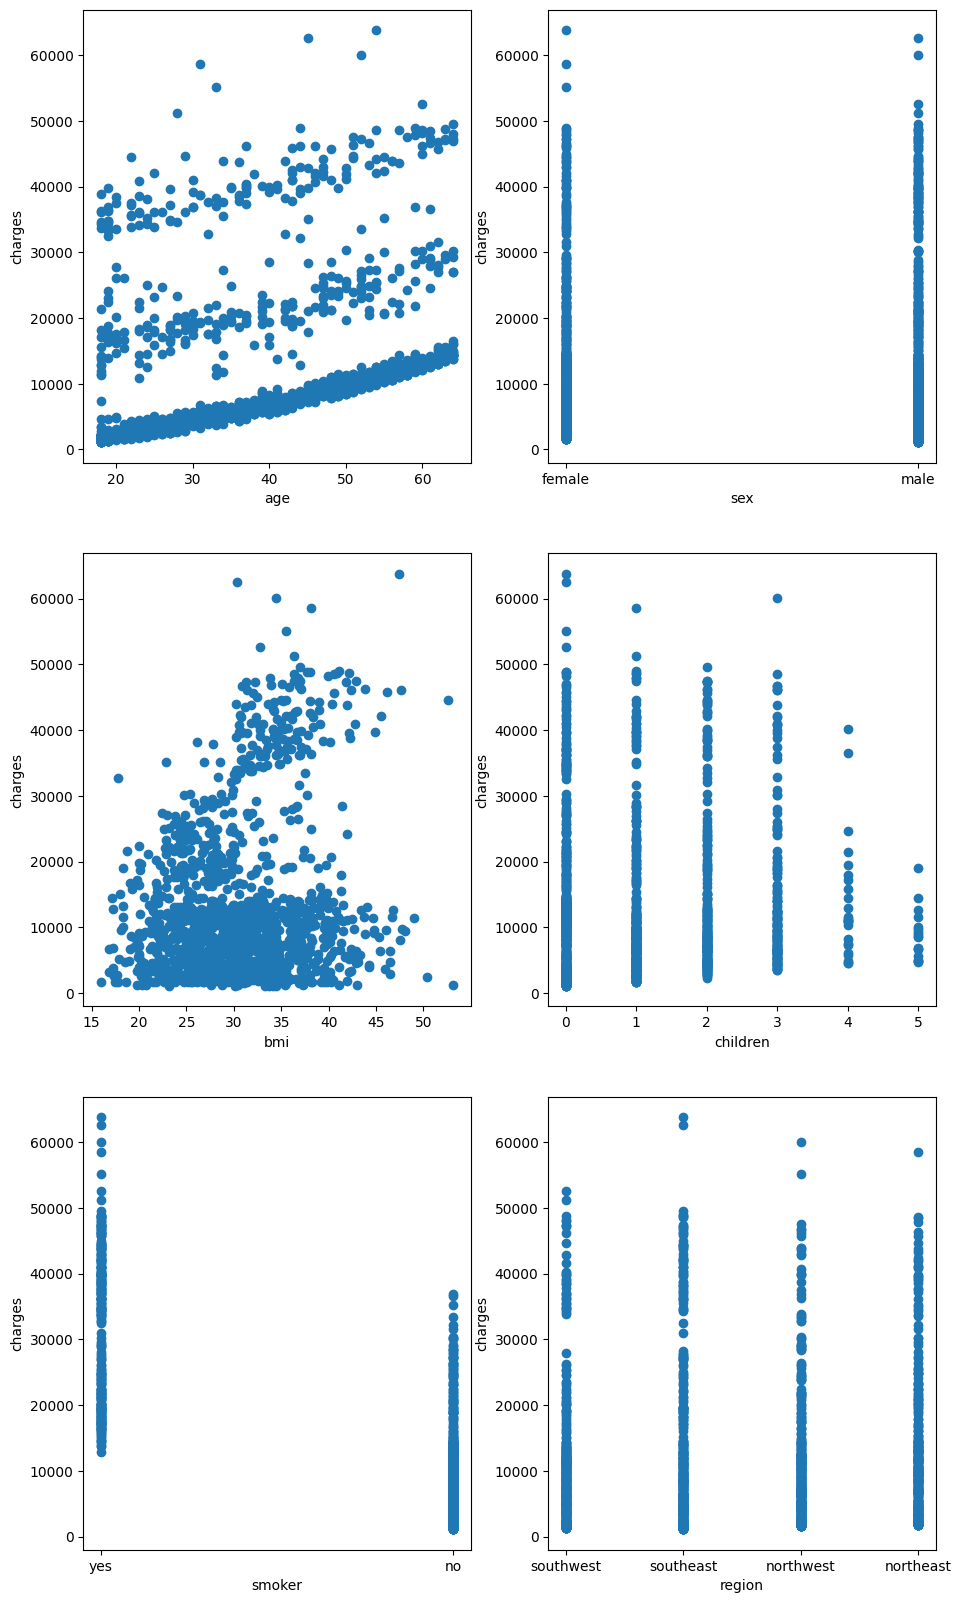

In [90]:
for ax, x in zip(plt.figure(figsize=(11,20)).subplots(3, 2).ravel(), df.columns):
    ax.scatter(df[x], df['charges'])
    ax.set_xlabel(x)
    ax.set_ylabel('charges')

plt.show()

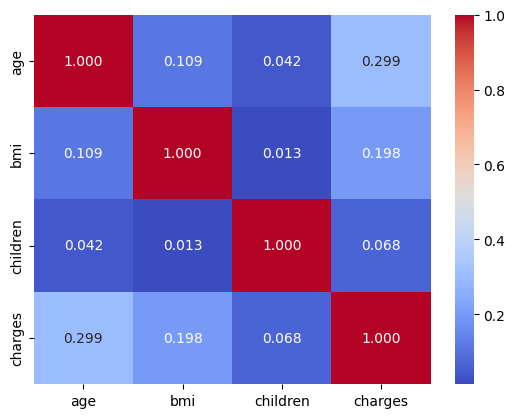

In [91]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt=".3f", cmap='coolwarm')
plt.show()

Теперь закодируем строковые признаки с помощью OneHotEncoder и посмотрим на поллную матрицу корреляции. Тут нужно использовать drop='first', т.к. первая колонка будет полностью отрицательно коррелировать со второй (если значений признака всего 2) для каждого закодированного признака.

In [92]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
df_encoded_part = pd.DataFrame(encoder.fit_transform(df.select_dtypes('str')))
df_encoded_part.columns = encoder.get_feature_names_out()
df_encoded_part.head()

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0


In [93]:
df_encoded = df.drop(df.select_dtypes('str').columns, axis='columns').join(df_encoded_part)
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0.0,1.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1.0,0.0,1.0,0.0,0.0


Вообще говоря, кодирование признаков нужно делать после `train_test_split`, чтобы модель не обучалась на тестовых данных, но в случае `OneHotEncoder` особо ничего не изменится, если мы сделаем кодеирование перед делением (если бы мы так сделали например со скейлером, то модель бы переобучалась). Сделав кодирование до деления, мы сможем нарисовать красивые диаграммы и получить больше информации при EDA.

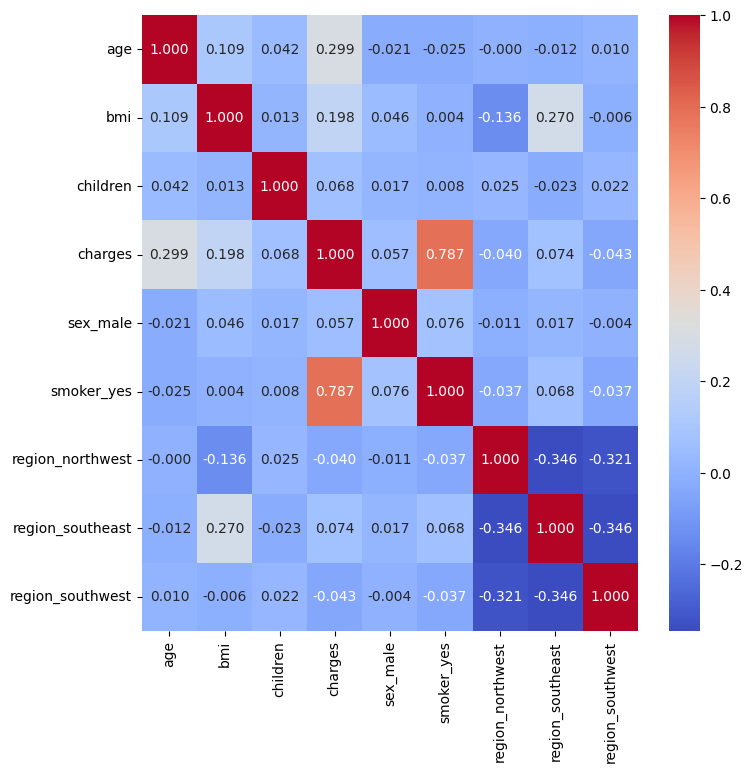

In [94]:
plt.figure(figsize=(8,8))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".3f", cmap='coolwarm')
plt.show()

Видно, что от того, курит ли человек, сильно зависят его расходы на медицинскую помощь.

### Подготовка данных

Теперь разделим данные на train и test используя `train_test_split()`. Это нужно, чтобы модель видела тестовые данные впервые (то есть чтобы она могла реально предсказыввать реальные данные, а не просто идеально "заучить" тренировочные данные и плохо предсказывать новые). Если бы мы не разделили данные, то при тестировании score модели получался не объективным (то есть буквально никак не показывал как модель решает поставленную задачу, а именно предсказание новых данных после обучения на тренировочных) потому что модель уже виделы эти данные при обучении. В данном случае исходные данные делятся на train и test в соотношении 80% на 20% соответственно.

In [95]:
X = df_encoded.drop(columns='charges')
y = df_encoded['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape)
print(X_test.shape)

X_train = pd.DataFrame(X_train)
X_train.columns = X.columns

X_test = pd.DataFrame(X_test)
X_test.columns = X.columns

(1070, 8)
(268, 8)


### Ответы на вопросы по пазделению выборки
**Обязательно объясните текстом:**
* **Сделали ли вы предобработку данных для случайного леса? Отличалась ли она от предобработки данных для линейной модели? Если до, то почему?**
* **Как именно вы разделили выборку?** 
* **На сколько частей нужно делить выборку при использовании кросс-валидации?**
* **Можно ли не использовать кросс-валидацию? Если да, то как делить выборку в таком случае?** 

---

1) Была сделана предобработка как для линейной регрессии (точно так же был использован OneHotEncoder с опцией drop='first' т. к. здесь это уместно и не испортит структуру деревьев, потому что возможных значений признаков мало).
2) Выборка делилась в соотношении 80/20 с помощью train_test_split().
3) Сначала датасет разбтвается на тренировочный и тестовый, а затем тренировочный разбивается на еще k кусков. При проведении валидации на каждой из k итераций, k-1 кусков объединяются как тренировочная выборка, а оставшийся кусок выступает в качестве тестовой выборки.
4) Можно, в таком случае либо делят выборку на train и test (обычно в пропорции 80 на 20).

### 2. Обучение Моделей
Обучим RandomForest на предобработанной выборке:

In [96]:
forest = RandomForestRegressor(n_estimators=100, max_depth=7, criterion='absolute_error', random_state=RANDOM_STATE)
forest.fit(X_train, y_train)
print('MAPE for RandomForestRegressor: ', mean_absolute_percentage_error(y_test, forest.predict(X_test)) * 100, '%')

MAPE for RandomForestRegressor:  16.555850684925282 %


Видно, что ошибка в предсказании цены за страховку достаточно существенная. Попробуем обучить одно дерево решений с той же глубиной:

In [97]:
tree = DecisionTreeRegressor(criterion='absolute_error', max_depth=7, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
print('MAPE for DecisionTreeRegressor: ', mean_absolute_percentage_error(y_test, tree.predict(X_test)) * 100, '%')

MAPE for DecisionTreeRegressor:  16.804711144845445 %


Получилось немного хуже чем у RandomForestRegressor. Теперь попробуем перебрать разные глубины и разное количество деревьев для RandomForest (тут пока что без grid search):

In [98]:
fitting_data = {}
for depth in range(1, 11):
    prev_score = 1
    best_n_estimators = 50
    for n_trees in range(50, 550, 50):
        forest.set_params(n_estimators=n_trees, max_depth=depth)
        forest.fit(X_train, y_train)
        temp = mean_absolute_percentage_error(y_test, forest.predict(X_test))
        if prev_score >= temp:
            best_n_estimators = n_trees
            prev_score = temp
    tree.set_params(max_depth=depth)
    tree.fit(X_train, y_train)
    fitting_data[depth] = {'tree score' : mean_absolute_percentage_error(y_test, tree.predict(X_test)) * 100, 'forest score' : prev_score * 100, 'forest n estimators' : best_n_estimators}

In [99]:
print(pd.DataFrame(fitting_data).T)

    tree score  forest score  forest n estimators
1    82.476469     81.870185                 50.0
2    38.891147     38.483250                500.0
3    21.512389     19.716072                350.0
4    16.522651     14.551542                100.0
5    14.773330     12.893485                250.0
6    14.902213     13.857734                400.0
7    16.804711     16.077187                400.0
8    17.308372     19.557808                250.0
9    20.298623     23.509240                250.0
10   21.385422     26.033575                200.0


Видно, что оптимальная глубина (для этой тестовой выборки!) равна 5. Теперь сравним скорость обучения моделей с лучшими результатами:

In [100]:
forest.set_params(max_depth=5, n_estimators=250)
tree.set_params(max_depth=5)

start_time = time.perf_counter()
forest.fit(X_train, y_train)
end_time = time.perf_counter()

print('forest fit time: ', end_time-start_time)

start_time = time.perf_counter()
tree.fit(X_train, y_train)
end_time = time.perf_counter()

print('tree fit time: ', end_time-start_time)

forest fit time:  1.7044138999990537
tree fit time:  0.01237079999918933


### Ответы на вопросы по обучению моделей
**Вопросы для анализа:**
* **Сравнение скорости:** сравните, какая модель обучалась быстрее. 
* **Можно ли добиться одинаковой или близкой к одинаковой скорости?**
* **Сравнение качества:** сравните результаты одного дерева и случайного леса.

---

1) Быстрее обучилась модель, состоящая только из одного дерева, что логично.
2) Можно, если использовать параллельные вычисления, то есть обучать деревья одновременно.
3) Случайный лес показал метрики лучше, но лучшие результаты различаются всего на 2 процента.

### 3. Оценка качества и сравнение моделей
Для начала получим лучшую модель Random Forest для кроссвалидации:

In [101]:
param_grid = {
    'n_estimators' : list(range(10, 501)),
    'max_depth' : list(range(1, 11))
}

search = RandomizedSearchCV(forest, param_grid, cv=5, scoring='neg_mean_absolute_percentage_error', random_state=RANDOM_STATE)
search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [1, 2, ...], 'n_estimators': [10, 11, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_percentage_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value

In [102]:
print('best cv score: ', search.best_score_ * -100, '%')
print('best cv parameters: ', search.best_params_)
print('best estimator score on test: ', mean_absolute_percentage_error(y_test, search.best_estimator_.predict(X_test)) * 100, '%')

best cv score:  15.372515584539997 %
best cv parameters:  {'n_estimators': 222, 'max_depth': 4}
best estimator score on test:  14.588219445957687 %


Получился лес с деревьями глубины 4. Теперь сравним с лучшей моделью линейной регрессии для кросс валидации из домашнего задания номер 4:

In [103]:
linreg = Pipeline(
    [
        ('scaler', StandardScaler(with_mean=False, with_std=False)),
        ('polyfeatures', PolynomialFeatures(degree=2, include_bias=True, interaction_only=True)),
        ('linreg', ElasticNet(alpha=100, l1_ratio=1.0, max_iter=2000, random_state=42))
    ]
)
linreg.fit(X_train, y_train)

linreg_cv_res = cross_validate(linreg, X_train, y_train, scoring='neg_mean_absolute_percentage_error', cv=5)
forest_cv_res = cross_validate(search.best_estimator_, X_train, y_train, scoring='neg_mean_absolute_percentage_error', cv=5)

print(pd.DataFrame(
    {
        'ElasticNet' : {'mean fit time' : linreg_cv_res['fit_time'].mean(), 'mean score time' : linreg_cv_res['score_time'].mean(), 'mean score' : str(linreg_cv_res['test_score'].mean() * -100) + ' %'},
        'RandomForestRegressor' : {'mean fit time' : forest_cv_res['fit_time'].mean(), 'mean score time' : forest_cv_res['score_time'].mean(), 'mean score' : str(forest_cv_res['test_score'].mean() * -100) + ' %'}
    }
))


                          ElasticNet RandomForestRegressor
mean fit time               0.016268              2.487049
mean score time             0.005491              0.053538
mean score       26.73287941116823 %  15.372515584539997 %


То есть случайный лес в данном случае лучше решает задачу предсказания цены страховки (минимизация метрики MAPE). Однако fit и score занимают больше времени.

Ответы на вопросы по сравнению моделей есть в домашнем задании номер 4 в самом конце.